In [40]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pymongo import MongoClient
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import resample
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer, util
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import spacy
import plotly.express as px
import joblib
import re
from nltk.corpus import stopwords
import nltk

In [41]:
# 2. Connect to MongoDB and Load Data
client = MongoClient('mongodb://localhost:27017/')
db = client['jobs_data']
collection = db['jobs']

# Query fields from MongoDB
cursor = collection.find({}, {
    'text': 1, 'core_position': 1, 'position': 1, 'orgAddress': 1, 'orgCompany': 1, 'name': 1, 
    'dateCreated': 1, 'orgTags': 1, 'core_skills': 1, 'contact': 1, 'salary': 1, 'url': 1
}).limit(33000)

data = list(cursor)
df = pd.DataFrame(data)

In [42]:
# 3. Flatten Nested Fields
def extract_nested(row, field, subfield):
    try:
        return row[field].get(subfield)
    except Exception:
        return None

# Flatten city and state from orgAddress
df['city'] = df.apply(lambda x: extract_nested(x, 'orgAddress', 'city'), axis=1)
df['state'] = df.apply(lambda x: extract_nested(x, 'orgAddress', 'region'), axis=1)

In [43]:
# 4. Clean Salary Field
def clean_salary(salary):
    try:
        if isinstance(salary, dict):
            return salary.get('value', None)
        elif isinstance(salary, (int, float)):
            return salary
    except Exception:
        return None
    return None

df['salary_cleaned'] = df['salary'].apply(clean_salary)

In [ ]:
# Make sure stopwords are downloaded
stop_words = set(stopwords.words('english'))

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

def clean_skills_with_nlp_better(skills_list):
    if not isinstance(skills_list, list):
        return []
    
    cleaned_skills = []
    
    for skill in skills_list:
        skill = skill.lower()
        # Basic cleanup
        skill = re.sub(r'[^a-zA-Z\s]', '', skill)
        
        # Parse skill phrase
        doc = nlp(skill)
        
        # Extract noun chunks (noun phrases like "data analysis", "customer service")
        for chunk in doc.noun_chunks:
            phrase = chunk.text.strip()
            if phrase and all(word not in stop_words for word in phrase.split()) and len(phrase) > 2:
                cleaned_skills.append(phrase)
        
        # Also add individual meaningful tokens if no noun_chunks found
        if not cleaned_skills:
            for token in doc:
                if (token.pos_ in ['NOUN', 'PROPN']) and (token.text not in stop_words) and (len(token.text) > 2):
                    lemma = token.lemma_.strip()
                    if lemma:
                        cleaned_skills.append(lemma)
    
    # Remove duplicates
    cleaned_skills = list(dict.fromkeys(cleaned_skills))
    
    return cleaned_skills

# Apply this new cleaner
df['core_skills_nlp_cleaned'] = df['core_skills'].apply(clean_skills_with_nlp_better)
df['skills_text_cleaned'] = df['core_skills_nlp_cleaned'].apply(lambda x: ' '.join(x))

In [46]:
df['skills_text_cleaned'].to_csv("skillscleaned.csv")

In [47]:
# -------------------------------
# 1. Clean the core_position Field
# -------------------------------
def clean_core_position(text):
    """
    Clean the core_position text by:
      - Removing extraneous quotes,
      - Stripping leading/trailing whitespace,
      - Removing unwanted punctuation.
    """
    if not isinstance(text, str):
        return text
    # Remove leading and trailing quotes and whitespace
    cleaned = text.strip().strip('"').strip()
    # Remove punctuation (keeping alphanumeric and spaces only)
    cleaned = re.sub(r'[^A-Za-z0-9\s]', '', cleaned)
    # Replace multiple spaces with a single space
    cleaned = re.sub(r'\s+', ' ', cleaned)
    return cleaned.strip()

# Apply cleaning to create a new column with cleaned data
df['core_position_cleaned'] = df['core_position'].apply(clean_core_position)

# -------------------------------
# 2. Generate Embeddings from Cleaned core_position
# -------------------------------
cleaned_positions = df['core_position_cleaned'].fillna("").tolist()
model_transformer = SentenceTransformer('all-MiniLM-L6-v2')
embeddings_cleaned = model_transformer.encode(cleaned_positions, show_progress_bar=True)

# -------------------------------
# 3. Cluster the Cleaned Embeddings with KMeans
# -------------------------------
num_clusters = 20  # Adjust as needed
kmeans_cleaned = KMeans(n_clusters=num_clusters, random_state=42)
clusters_cleaned = kmeans_cleaned.fit_predict(embeddings_cleaned)
df['core_position_cluster'] = clusters_cleaned

# -------------------------------
# 4. Inspect the Clusters
# -------------------------------
cluster_summary = {}
for cluster in range(num_clusters):
    sample_positions = df[df['core_position_cluster'] == cluster]['core_position_cleaned'].dropna().unique()[:10]
    cluster_summary[cluster] = sample_positions

print("Cluster Summary (cleaned core_position):")
for cluster, positions in cluster_summary.items():
    print(f"\nCluster {cluster}:")
    for pos in positions:
        print(f" - {pos}")

# -------------------------------
# 5. Manual Labeling of Clusters
# -------------------------------
manual_labels = {
    0: "Customer Service & Sales",
    1: "Laboratory & Technical Support",
    2: "Nursing & Healthcare Assistants",
    3: "Hotel & Hospitality Management",
    4: "Hair Stylists & Salon Professionals",
    5: "Administrative & Payroll Support",
    6: "Transportation & Logistics",
    7: "Payroll & Operational Supervisors",
    8: "Accounting & Financial Management",
    9: "Healthcare & Medical Support",
    10: "Engineering & Technical Design",
    11: "Household & Care Services",
    12: "Specialist & Administrative Support",
    13: "Creative & Design Roles",
    14: "Laboratory & Medical Research",
    15: "Culinary & Food Services",
    16: "Operations & Inventory Management",
    17: "Retail & Sales Support",
    18: "Therapy, Counseling & Social Work",
    19: "Teaching & Performing Arts"
}

df['job_category'] = df['core_position_cluster'].map(manual_labels)

print("\nCounts of Manual Labels:")
print(df['job_category'].value_counts())

Batches: 100%|██████████| 1032/1032 [00:52<00:00, 19.58it/s]


Cluster Summary (cleaned core_position):

Cluster 0:
 - Customer Service Representative
 - Client Service Representative
 - Representative
 - Customer Service RepresentativeAccounting Clerk
 - Sales Representative for Mineral Oil Business
 - Sales Representative
 - Ad Sales Representative
 - Call Center Representative
 - Sales Representative for Lumber and Building Materials
 - Media Sales Representative

Cluster 1:
 - Test Technician
 - Lab Technician
 - Media preparation technician
 - Analytical Laboratory Technician
 - Quality Control Laboratory Technician
 - Cell Biology Laboratory Technician
 - Greenhouse Technician
 - Microbiology Laboratory Technician
 - Biological Laboratory Technician
 - Medical Laboratory Technician

Cluster 2:
 - Certified Nursing AssistantChronic Health Care Assistant
 - Family Nurse Practitioner
 - Licensed Practical Nurse LPN providing direct patient care under the supervision of physicians and other healthcare professionals in a medical setting
 - Nurse 

In [ ]:
def extract_position_name(position_obj):
    """
    Extracts the 'name' from the nested 'position' dictionary.
    If not found, returns None.
    """
    if isinstance(position_obj, dict):
        return position_obj.get('name', None)
    return None

df['position_name'] = df['position'].apply(extract_position_name)

# %%
# Use the previously loaded model_transformer for career level inference
# Define career level references
career_reference = {
    'STUDENT': "This is a student internship",
    'JUNIOR': "This is a junior level position",
    'SENIOR': "This is a senior level position",
    'CHIEF': "This is a chief or director level role"
}

career_reference_embeddings = {level: model_transformer.encode(desc) for level, desc in career_reference.items()}

def infer_career_level_nlp(job_title, extra_text=""):
    if not isinstance(job_title, str) or job_title.strip() == '':
        return 'OTHER'
    
    combined_input = (job_title + " " + extra_text).strip()
    job_embedding = model_transformer.encode(combined_input)
    
    similarities = {level: util.cos_sim(job_embedding, emb)[0][0].item() for level, emb in career_reference_embeddings.items()}
    best_match = max(similarities, key=similarities.get)
    return best_match

df['career_level_nlp'] = df.apply(lambda row: infer_career_level_nlp(row['position_name'], row['skills_text_cleaned']), axis=1)

In [ ]:
print(df[['position_name', 'career_level_nlp']].head(20))
print("Career Level Counts:")
print(df['career_level_nlp'].value_counts())

                                        position_name career_level_nlp
0                                     Account Manager            CHIEF
1                        Music Teacher, Band Director           JUNIOR
2                      Floral Clerk FT Chapel Hill NC           SENIOR
3   Audio and Video Transcription - Flexible Sched...          STUDENT
4                        Sticker Production Assistant           SENIOR
5                               Specifications Writer          STUDENT
6   Social Media Evaluator - Dynamic Work Opportun...          STUDENT
7                   Photo Color Correction Specialist            CHIEF
8                                      Service Writer          STUDENT
9                    UAF CLA Term Instructor of Piano           JUNIOR
10               Dance Instructor Litehouse/Sandpoint           JUNIOR
11                                   Dance Instructor           JUNIOR
12           Dance Instructor/Choreographer - Phoenix           SENIOR
13  Co

In [ ]:
# Create a final version of the DataFrame
df_final = df.copy()
df_final.to_pickle('final_df.pkl')
print("Final DataFrame saved as 'final_df.pkl'.")
print(df_final['city'].value_counts().head(20))

Final DataFrame saved as 'final_df.pkl'.
city
New York        459
Houston         403
Dallas          359
                331
Atlanta         327
Chicago         315
Austin          307
Boston          301
Phoenix         280
Minneapolis     260
Albuquerque     254
Columbus        249
Los Angeles     232
Seattle         226
Charlotte       223
Portland        219
Raleigh         215
Denver          215
Indianapolis    206
Hartford        205
Name: count, dtype: int64


In [ ]:
# Create Combined Text for Better Features
df_final['combined_text'] = (
    df_final['skills_text_cleaned'].fillna('') + " " + df_final['position_name'].fillna('')
)
print("Combined text feature created successfully.")

Combined text feature created successfully.


In [ ]:
# Balancing Dataset for career_level_nlp classification
# Create a DataFrame with features and the target variable
df_model = pd.DataFrame({
    'combined_text': df_final['combined_text'].fillna(''),
    'career_level_nlp': df_final['career_level_nlp'],
    'job_category': df_final['job_category'],
})

# Determine the minimum class count across all career_level_nlp labels
min_count = df_model['career_level_nlp'].value_counts().min()

# Resample each class to ensure balanced representation
balanced_list = []
for label in df_model['career_level_nlp'].unique():
    class_subset = df_model[df_model['career_level_nlp'] == label]
    # Resample each class to have min_count samples
    balanced_subset = resample(class_subset, replace=True, n_samples=min_count, random_state=42)
    balanced_list.append(balanced_subset)

df_balanced = pd.concat(balanced_list)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# 2. TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df_balanced['combined_text'])
y = df_balanced['job_category']

In [ ]:
# 3. Encode Labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 5. Train XGBoost Model
xgb_classifier = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_estimators=300,
    max_depth=15,
    learning_rate=0.1,
    random_state=42
)
xgb_classifier.fit(X_train, y_train)

c:\Users\akash\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning:

[18:11:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=15, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=5, ...)


Classification Report (XGBoost):
                                   precision    recall  f1-score   support

 Administrative & Payroll Support       0.92      0.89      0.90       341
          Creative & Design Roles       0.89      0.87      0.88       345
   Hotel & Hospitality Management       0.91      0.92      0.91       362
   Laboratory & Technical Support       0.97      0.96      0.96       313
Operations & Inventory Management       0.82      0.87      0.84       352

                         accuracy                           0.90      1713
                        macro avg       0.90      0.90      0.90      1713
                     weighted avg       0.90      0.90      0.90      1713



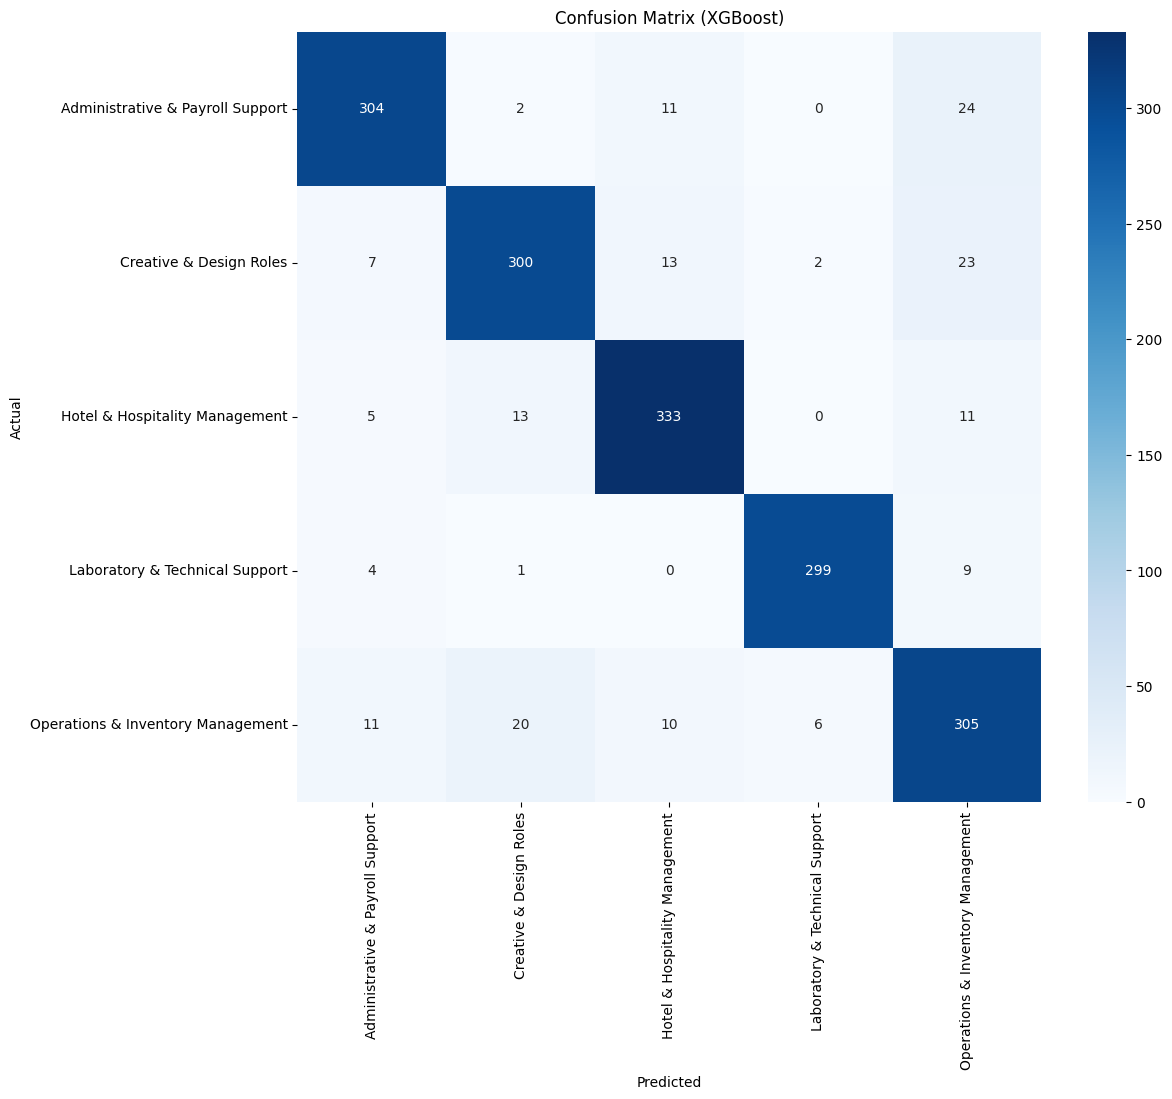

In [ ]:
# 6. Predictions
y_pred = xgb_classifier.predict(X_test)

# 7. Decode Predictions
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)

# 8. Evaluate
print("\nClassification Report (XGBoost):")
print(classification_report(y_test_labels, y_pred_labels))

# 9. Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=label_encoder.classes_)
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues', annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (XGBoost)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# 10. Save Model, Vectorizer and Label Encoder
joblib.dump(xgb_classifier, 'final_xgboost_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
print("Final model, vectorizer, and label encoder saved successfully.")

Final model, vectorizer, and label encoder saved successfully.


In [ ]:
# Get feature importance scores from XGBoost
importances = xgb_classifier.feature_importances_
feature_names = vectorizer.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

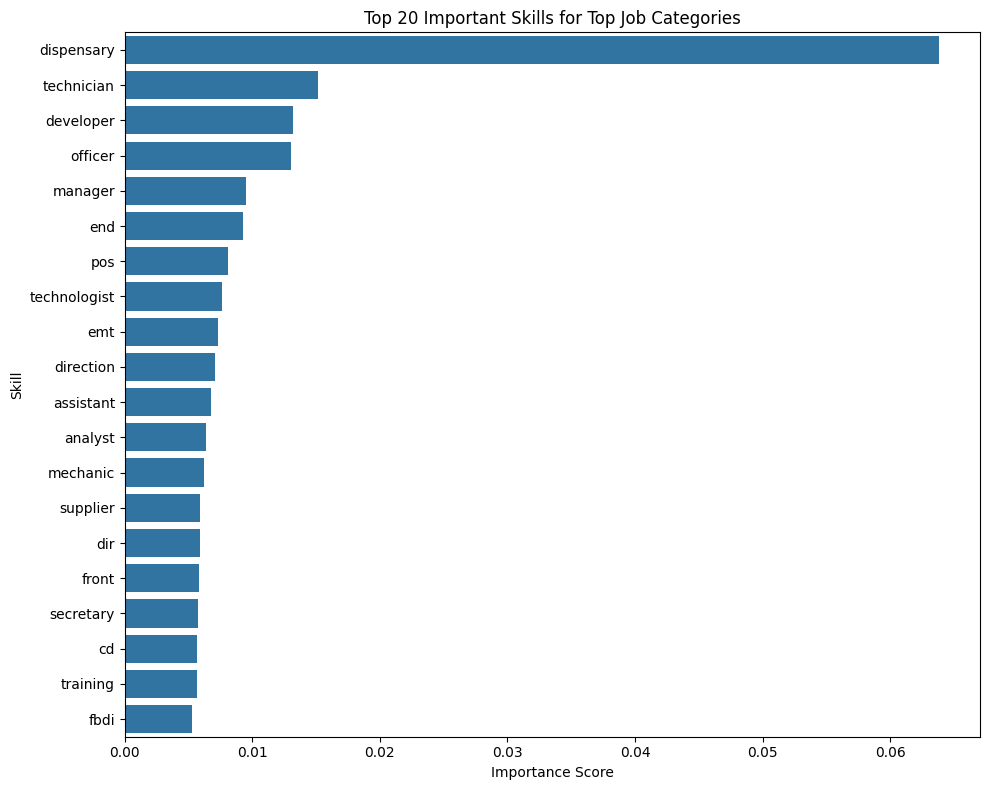

In [ ]:
# Plot top 20 important skills/features
plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Important Skills for Job Prediction')
plt.show()

In [ ]:
# 1. Flatten all skills into a single list
all_skills = df['core_skills_nlp_cleaned'].explode()

# 2. Count skill frequencies
skill_counts = Counter(all_skills)

# 3. Get Top 20 skills
top_skills = skill_counts.most_common(20)
skills, counts = zip(*top_skills)

# 4. Create Interactive Bar Plot for Skills
fig = px.bar(
    x=counts,
    y=skills,
    orientation='h',
    title='Top 20 Most In-Demand Skills',
    labels={'x': 'Frequency', 'y': 'Skill'},
    color=counts,
    color_continuous_scale='Blues'
)
fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    template='plotly_white',
    height=600,
    width=900
)
fig.show()

In [ ]:
# 1. Count job postings by city
city_counts = df['city'].value_counts().dropna().head(20)

# 2. Create Interactive Bar Plot for Cities
fig = px.bar(
    x=city_counts.values,
    y=city_counts.index,
    orientation='h',
    title='Top 20 Cities by Number of Job Postings',
    labels={'x': 'Number of Jobs', 'y': 'City'},
    color=city_counts.values,
    color_continuous_scale='Purples'
)
fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    template='plotly_white',
    height=600,
    width=900
)
fig.show()

In [ ]:
# 1. Ensure salary is numeric and create salary box plot by career level
df['salary_cleaned'] = pd.to_numeric(df['salary_cleaned'], errors='coerce')
salary_df = df.dropna(subset=['salary_cleaned', 'career_level_nlp'])

fig = px.box(
    salary_df,
    x='career_level_nlp',
    y='salary_cleaned',
    title='Salary Distribution by Career Level (Fixed & Clean)',
    labels={'career_level_nlp': 'Career Level', 'salary_cleaned': 'Salary (USD)'},
    color='career_level_nlp',
    color_discrete_sequence=px.colors.qualitative.Set2,
    points='all'
)
fig.update_layout(
    template='plotly_white',
    xaxis_tickangle=-45,
    height=600,
    width=1000
)
fig.show()

In [ ]:
# 1. Group job categories and create a Pie Chart
category_counts = df['career_level_nlp'].value_counts().reset_index()
category_counts.columns = ['career_level_nlp', 'count']

others_count = category_counts[category_counts['career_level_nlp'] == 'Other']['count'].sum()
filtered_categories = category_counts[category_counts['career_level_nlp'] != 'Other']

fig = px.pie(
    filtered_categories,
    values='count',
    names='career_level_nlp',
    title='Job Category Distribution (Excluding "Other")',
    color_discrete_sequence=px.colors.qualitative.Pastel1,
    hole=0.3
)
fig.update_traces(textinfo='percent+label')
fig.update_layout(
    template='plotly_white',
    height=600,
    width=800,
    annotations=[dict(
        text=f"Others ({round(others_count / category_counts['count'].sum() * 100, 1)}%)",
        x=0.5, y=-0.1, showarrow=False,
        font=dict(size=14)
    )]
)
fig.show()